# Лабораторная работа: Кластеризация текстов (Amazon Fine Food Reviews)

**Задачи:**
- Предобработка текстов
- Векторизация: TF-IDF и SBERT
- Кластеризация (K-Means)
- Метрики качества кластеризации
- Топ-слова и облака слов для каждого кластера

## 0. Установка зависимостей

In [1]:
!pip install sentence-transformers keybert wordcloud nltk scikit-learn pandas numpy matplotlib seaborn umap-learn

## 1. Импорты и настройки

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from wordcloud import WordCloud
from keybert import KeyBERT

from sklearn.decomposition import PCA
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP не установлен, будет использован PCA для визуализации")

warnings.filterwarnings('ignore')

for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab']:
    nltk.download(resource, quiet=True)

RANDOM_STATE = 42
N_CLUSTERS = 5

c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Загрузка и обрезка датасета

> Если у вас ещё нет датасета — скачайте его с [Kaggle](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews) и укажите путь к файлу `Reviews.csv` в переменной `DATA_PATH`.

In [3]:
DATA_PATH = '../data/Reviews.csv'  
SAMPLE_SIZE = 5000 

print(f"Загрузка датасета из: {DATA_PATH}")
print(f"Размер выборки: {SAMPLE_SIZE} строк")

df_full = pd.read_csv(DATA_PATH)
print(f"\nПолный датасет: {df_full.shape[0]:,} строк, {df_full.shape[1]} столбцов")
print(f"Столбцы: {list(df_full.columns)}")

df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"\nВыборка: {df.shape[0]:,} строк")

df.to_csv('../data/Reviews_sample.csv', index=False)

Загрузка датасета из: ../data/Reviews.csv
Размер выборки: 5000 строк

Полный датасет: 568,454 строк, 10 столбцов
Столбцы: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Выборка: 5,000 строк


In [4]:
print(df[['ProductId', 'UserId', 'Score', 'Summary', 'Text']].head(3).to_string())
print(f"\nПропуски в Text: {df['Text'].isna().sum()}")

df = df.dropna(subset=['Text']).reset_index(drop=True)
print(f"После удаления пропусков: {len(df)} строк")

    ProductId          UserId  Score                                       Summary                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        Text
0  B000EVG8J2  A1L01D2BD3RKVO      5  Crunchy & Good Gluten-Free Sandwich Cookies!       Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I've satisfied my sweet tooth sooner!  The choco

## 3. Предварительная обработка текстов

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

extra_stopwords = {'br', 'product', 'food', 'one', 'get', 'also', 'would', 'could', 'like', 'use', 'make', 'got'}
stop_words = stop_words | extra_stopwords


def clean_text(text: str) -> str:
    # Удаление HTML-тегов
    text = re.sub(r'<[^>]+>', ' ', text)
    # Удаление URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Удаление смайликов и прочих unicode-символов вне ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Удаление знаков препинания и цифр
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Приведение к нижнему регистру
    text = text.lower()
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def lemmatize_text(text: str) -> str:
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return ' '.join(tokens)


print("Предобработка текстов...")
df['text_clean'] = df['Text'].apply(clean_text)
df['text_lemma'] = df['text_clean'].apply(lemmatize_text)

df = df[df['text_lemma'].str.strip().str.len() > 10].reset_index(drop=True)

print(f"Предобработка завершена. Осталось {len(df)} документов.")

# Пример
idx = 0
print(f"\n--- Пример (строка {idx}) ---")
print(f"Исходный:      {df['Text'].iloc[idx][:200]}...")
print(f"Очищенный:     {df['text_clean'].iloc[idx][:200]}...")
print(f"Лемматизир.:   {df['text_lemma'].iloc[idx][:200]}...")

Предобработка текстов...
Предобработка завершена. Осталось 5000 документов.

--- Пример (строка 0) ---
Исходный:      Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  S...
Очищенный:     having tried a couple of other brands of gluten free sandwich cookies these are the best of the bunch they re crunchy and true to the texture of the other real cookies that aren t gluten free some mig...
Лемматизир.:   tried couple brand gluten free sandwich cooky best bunch crunchy true texture real cooky gluten free might think filling make bit sweet mean satisfied sweet tooth sooner chocolate version glutino good...


## 4. Векторизация текстов

### 4.1 TF-IDF

In [6]:
print("Векторизация TF-IDF...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_lemma'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"   TF-IDF матрица: {tfidf_matrix.shape}")
print(f"   Размер словаря: {len(tfidf_feature_names)} токенов")

Векторизация TF-IDF...
   TF-IDF матрица: (5000, 5000)
   Размер словаря: 5000 токенов


### 4.2 SBERT (sentence-transformers)

In [8]:
df['text_for_sbert'] = df['text_clean'].apply(lambda x: ' '.join(x.split()[:150]))

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

sbert_embeddings = sbert_model.encode(
    df['text_for_sbert'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    device='cpu'
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6407.70it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 40/40 [01:08<00:00,  1.71s/it]


## 5. Кластеризация (K-Means)

### 5.1 Подбор оптимального числа кластеров (Elbow Method)

Вычисление инерции для разных k...


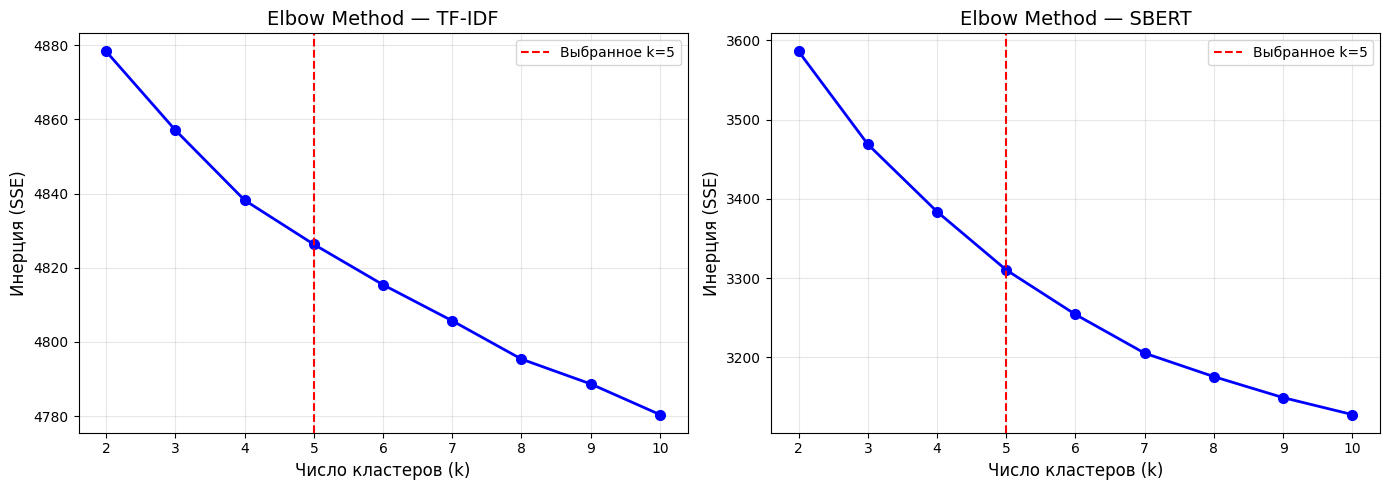


Выбранное количество кластеров: k = 5


In [9]:
from sklearn.preprocessing import normalize

sbert_norm = normalize(sbert_embeddings)

inertias_tfidf = []
inertias_sbert = []
k_range = range(2, 11)

print("Вычисление инерции для разных k...")
for k in k_range:
    km_t = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_t.fit(tfidf_matrix)
    inertias_tfidf.append(km_t.inertia_)

    km_s = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_s.fit(sbert_norm)
    inertias_sbert.append(km_s.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, inertias, title in zip(axes,
                                [inertias_tfidf, inertias_sbert],
                                ['TF-IDF', 'SBERT']):
    ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
    ax.axvline(x=N_CLUSTERS, color='red', linestyle='--', label=f'Выбранное k={N_CLUSTERS}')
    ax.set_xlabel('Число кластеров (k)', fontsize=12)
    ax.set_ylabel('Инерция (SSE)', fontsize=12)
    ax.set_title(f'Elbow Method — {title}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nВыбранное количество кластеров: k = {N_CLUSTERS}")

### 5.2 Обучение K-Means

In [10]:

kmeans_tfidf = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20, max_iter=500)
labels_tfidf = kmeans_tfidf.fit_predict(tfidf_matrix)

kmeans_sbert = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20, max_iter=500)
labels_sbert = kmeans_sbert.fit_predict(sbert_norm)

df['cluster_tfidf'] = labels_tfidf
df['cluster_sbert'] = labels_sbert

print("Распределение по кластерам (TF-IDF):")
print(pd.Series(labels_tfidf).value_counts().sort_index().to_string())

print("\nРаспределение по кластерам (SBERT):")
print(pd.Series(labels_sbert).value_counts().sort_index().to_string())

Распределение по кластерам (TF-IDF):
0    2453
1     412
2     566
3     557
4    1012

Распределение по кластерам (SBERT):
0     638
1    1385
2     639
3     807
4    1531


## 6. Метрики качества кластеризации

In [11]:
import scipy.sparse

tfidf_dense = tfidf_matrix.toarray()

def compute_metrics(X, labels, name):
    sil  = silhouette_score(X, labels, metric='cosine', sample_size=min(2000, len(labels)), random_state=RANDOM_STATE)
    db   = davies_bouldin_score(X, labels)
    ch   = calinski_harabasz_score(X, labels)
    print(f"\n{'='*50}")
    print(f"  Метрики кластеризации: {name}")
    print(f"{'='*50}")
    print(f"  Silhouette Score     : {sil:.4f}  (чем ближе к 1, тем лучше; >0.2 — приемлемо)")
    print(f"  Davies-Bouldin Score : {db:.4f}  (чем меньше, тем лучше; <1.5 — приемлемо)")
    print(f"  Calinski-Harabasz    : {ch:.2f} (чем больше, тем лучше)")
    return {'method': name, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}

metrics_tfidf = compute_metrics(tfidf_dense, labels_tfidf, 'TF-IDF + K-Means')
metrics_sbert = compute_metrics(sbert_norm,  labels_sbert, 'SBERT  + K-Means')

metrics_df = pd.DataFrame([metrics_tfidf, metrics_sbert]).set_index('method')
print("\n", metrics_df.to_string())


  Метрики кластеризации: TF-IDF + K-Means
  Silhouette Score     : 0.0136  (чем ближе к 1, тем лучше; >0.2 — приемлемо)
  Davies-Bouldin Score : 11.5098  (чем меньше, тем лучше; <1.5 — приемлемо)
  Calinski-Harabasz    : 19.96 (чем больше, тем лучше)

  Метрики кластеризации: SBERT  + K-Means
  Silhouette Score     : 0.0872  (чем ближе к 1, тем лучше; >0.2 — приемлемо)
  Davies-Bouldin Score : 4.0480  (чем меньше, тем лучше; <1.5 — приемлемо)
  Calinski-Harabasz    : 177.46 (чем больше, тем лучше)

                   silhouette  davies_bouldin  calinski_harabasz
method                                                         
TF-IDF + K-Means    0.013608       11.509752          19.962966
SBERT  + K-Means    0.087183        4.048008         177.462616


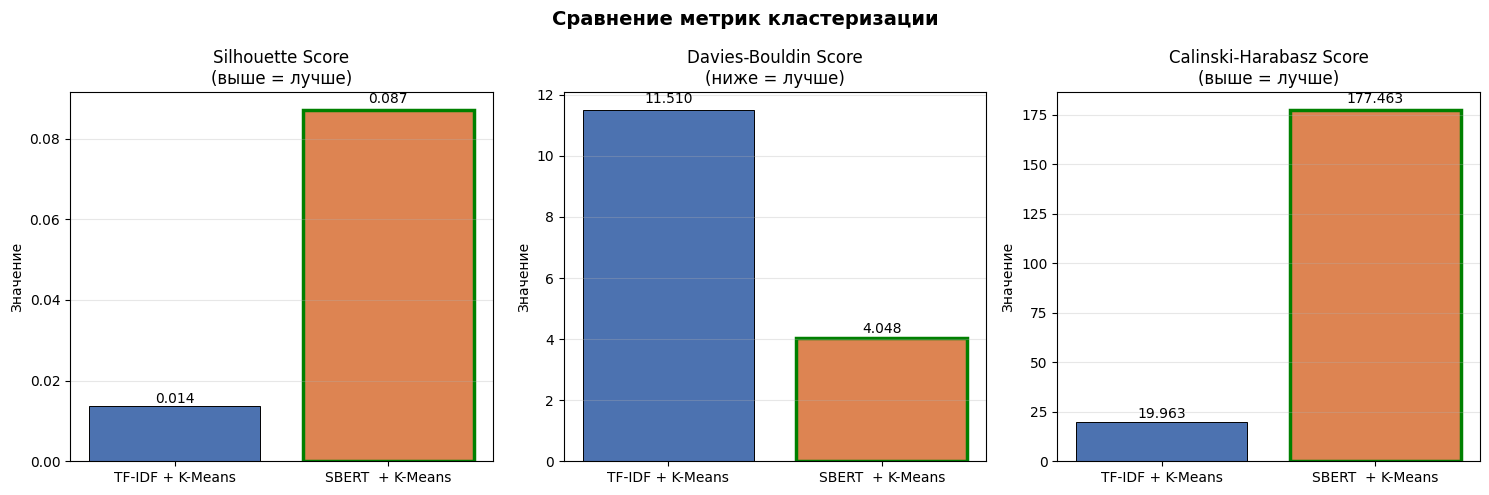

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0', '#DD8452']

for ax, (col, title, higher_better) in zip(axes, [
    ('silhouette',        'Silhouette Score\n(выше = лучше)',       True),
    ('davies_bouldin',    'Davies-Bouldin Score\n(ниже = лучше)',   False),
    ('calinski_harabasz', 'Calinski-Harabasz Score\n(выше = лучше)', True),
]):
    vals = metrics_df[col].values
    bars = ax.bar(metrics_df.index, vals, color=colors, edgecolor='black', linewidth=0.7)
    best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best_idx].set_edgecolor('green')
    bars[best_idx].set_linewidth(2.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Значение')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение метрик кластеризации', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Интерпретация метрик

| Метрика | Описание | Чем лучше |
|---|---|---|
| **Silhouette Score** | Измеряет, насколько объект похож на свой кластер по сравнению с соседними. Диапазон [-1, 1]. | Ближе к **1** |
| **Davies-Bouldin Score** | Среднее отношение суммы разброса кластеров к расстоянию между центрами. | Ближе к **0** |
| **Calinski-Harabasz** | Отношение дисперсии между кластерами к дисперсии внутри кластеров. | Чем **больше**, тем лучше |

## 7. Визуализация кластеров (2D)

Снижение размерности для визуализации...


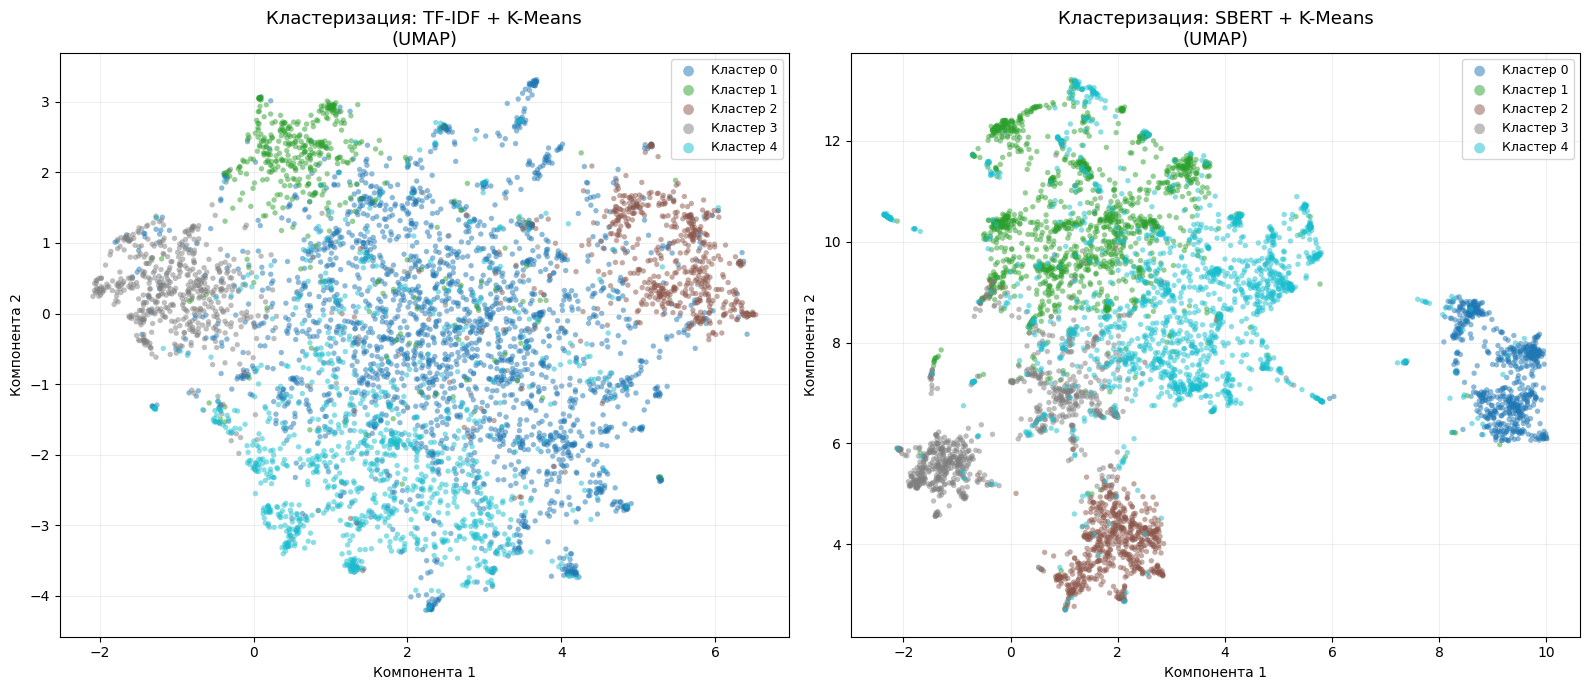

In [13]:
def reduce_2d(X, method='pca'):
    if method == 'umap' and UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
        return reducer.fit_transform(X)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    return pca.fit_transform(X)

print("Снижение размерности для визуализации...")
vis_method = 'umap' if UMAP_AVAILABLE else 'pca'

coords_tfidf = reduce_2d(tfidf_dense, vis_method)
coords_sbert = reduce_2d(sbert_norm,  vis_method)

palette = plt.cm.get_cmap('tab10', N_CLUSTERS)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, labels, title in zip(
    axes,
    [coords_tfidf, coords_sbert],
    [labels_tfidf, labels_sbert],
    ['TF-IDF + K-Means', 'SBERT + K-Means']
):
    for cl in range(N_CLUSTERS):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[palette(cl)], label=f'Кластер {cl}',
                   alpha=0.5, s=15, edgecolors='none')
    ax.set_title(f'Кластеризация: {title}\n({vis_method.upper()})', fontsize=13)
    ax.legend(markerscale=2, loc='best', fontsize=9)
    ax.set_xlabel('Компонента 1')
    ax.set_ylabel('Компонента 2')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('clusters_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Топ-слова по кластерам

### 8.1 TF-IDF — топ-слова из центроидов

In [14]:
TOP_N = 15

top_words_tfidf = {}
centers = kmeans_tfidf.cluster_centers_ 

print(f"Топ-{TOP_N} слов по кластерам (TF-IDF):\n")
for cl in range(N_CLUSTERS):
    top_indices = centers[cl].argsort()[::-1][:TOP_N]
    words = [(tfidf_feature_names[i], round(centers[cl][i], 4)) for i in top_indices]
    top_words_tfidf[cl] = words
    word_str = ', '.join([w for w, _ in words])
    print(f"  Кластер {cl} ({(labels_tfidf==cl).sum()} отзывов): {word_str}")

Топ-15 слов по кластерам (TF-IDF):

  Кластер 0 (2453 отзывов): good, great, taste, price, flavor, amazon, love, time, store, buy, best, find, much, really, better
  Кластер 1 (412 отзывов): tea, green tea, taste, green, flavor, drink, bag, cup, tea bag, good, love, box, great, stash, drinking
  Кластер 2 (566 отзывов): dog, treat, cat, love, dog love, eat, give, dry, good, chew, vet, year, old, great, ingredient
  Кластер 3 (557 отзывов): coffee, cup, flavor, good, strong, roast, taste, cup coffee, bold, blend, smooth, great, bitter, pod, dark
  Кластер 4 (1012 отзывов): chocolate, taste, snack, chip, bar, great, good, sweet, love, flavor, sugar, free, calorie, cooky, eat


### 8.2 SBERT — топ-слова через KeyBERT

In [15]:
print("Загрузка KeyBERT...")
kw_model = KeyBERT(model='paraphrase-MiniLM-L6-v2')

top_words_sbert = {}
KEYBERT_SAMPLE = 200

print(f"\nТоп-{TOP_N} слов по кластерам (SBERT / KeyBERT):\n")
for cl in range(N_CLUSTERS):
    cluster_texts = df[df['cluster_sbert'] == cl]['text_lemma'].tolist()
    sample_texts = cluster_texts[:KEYBERT_SAMPLE]
    combined = ' '.join(sample_texts)

    keywords = kw_model.extract_keywords(
        combined,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=TOP_N,
        use_mmr=True,
        diversity=0.5
    )
    top_words_sbert[cl] = keywords
    word_str = ', '.join([kw for kw, _ in keywords])
    print(f"  Кластер {cl} ({(labels_sbert==cl).sum()} отзывов): {word_str}")

Загрузка KeyBERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4989.53it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Топ-15 слов по кластерам (SBERT / KeyBERT):

  Кластер 0 (638 отзывов): chewable treat, dog bit, month cat, dog vendor, wolf mix, picky able, problem love, bought nearly, pop bolt, litterbox, barked frustrated, passed dog, canidae sciencediet, order receive, unseal package
  Кластер 1 (1385 отзывов): flavor bread, bit oat, bit gritty, sweet expected, wheat bite, gum slightly, blueberry yum, snyder pretzel, gluten yay, treat trying, ordered mini, surprised error, teeth broke, share saw, deal coming
  Кластер 2 (639 отзывов): lover coffee, christmas tried, taste disappointed, maker truly, newman bold, preference marley, wish senseo, didnt realize, folgers buy, grm serving, pod compare, bialetti brikka, told doctor, half pouch, pay make
  Кластер 3 (807 отзывов): yorkshire tea, multipack good, bought chocolate, cent love, leave bitter, refreshing wait, expensive finally, able stash, surprised pleased, opinion undrinkable, black pretty, lot naturade, chinese restarants, outstanding blackb

## 9. Облака слов (WordCloud)

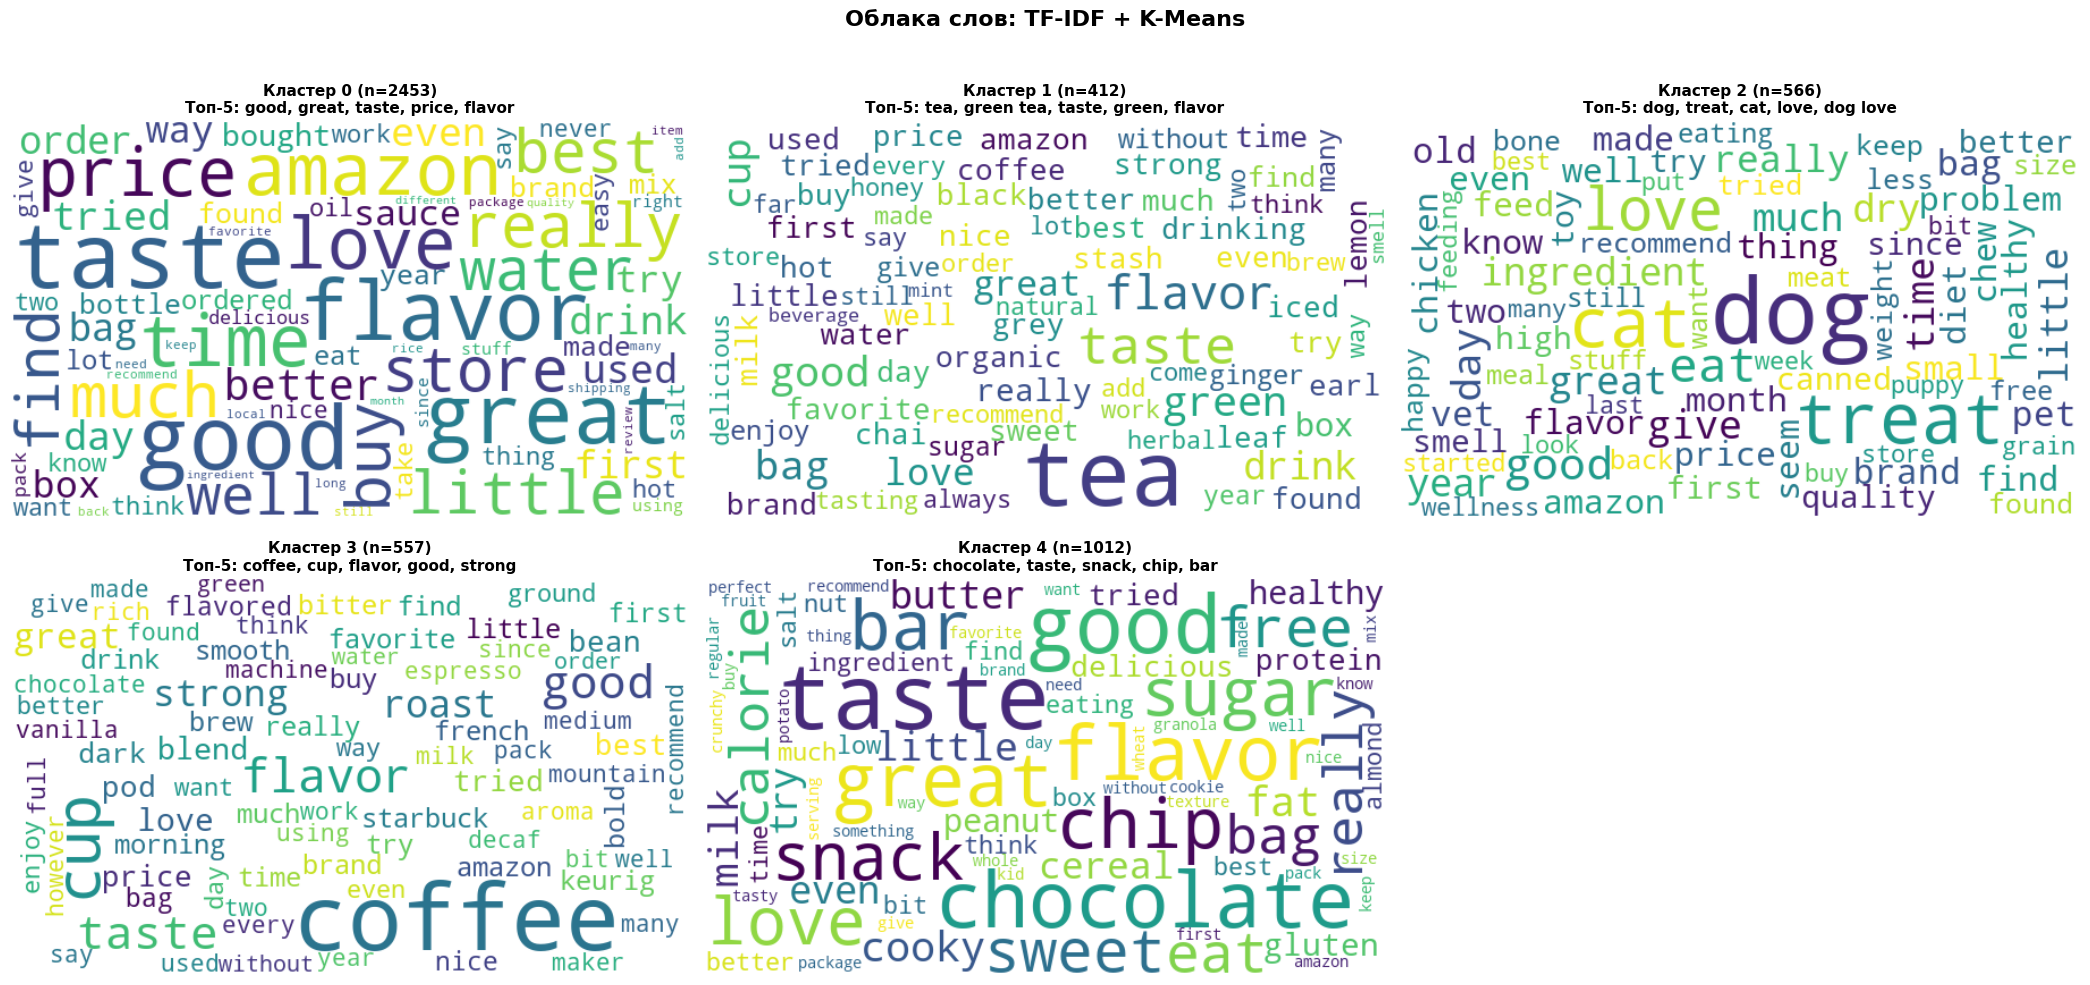

✅ Сохранено: wordclouds_tfidf.png


In [16]:
WC_PARAMS = dict(
    background_color='white',
    max_words=80,
    max_font_size=80,
    width=600,
    height=350,
    collocations=False,
    stopwords=stop_words
)

def plot_wordclouds(df_col, labels, top_words_dict, method_name, filename):
    ncols = min(N_CLUSTERS, 3)
    nrows = (N_CLUSTERS + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    for cl in range(N_CLUSTERS):
        texts = df[labels == cl][df_col].tolist()
        combined = ' '.join(texts)
        if not combined.strip():
            axes[cl].set_visible(False)
            continue
        wc = WordCloud(**WC_PARAMS).generate(combined)
        axes[cl].imshow(wc, interpolation='bilinear')
        n_docs = (labels == cl).sum()
        top5 = ', '.join([w for w, _ in top_words_dict[cl][:5]])
        axes[cl].set_title(f'Кластер {cl} (n={n_docs})\nТоп-5: {top5}',
                            fontsize=11, fontweight='bold')
        axes[cl].axis('off')

    for i in range(N_CLUSTERS, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Облака слов: {method_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Сохранено: {filename}")


plot_wordclouds(
    df_col='text_lemma',
    labels=df['cluster_tfidf'],
    top_words_dict=top_words_tfidf,
    method_name='TF-IDF + K-Means',
    filename='wordclouds_tfidf.png'
)

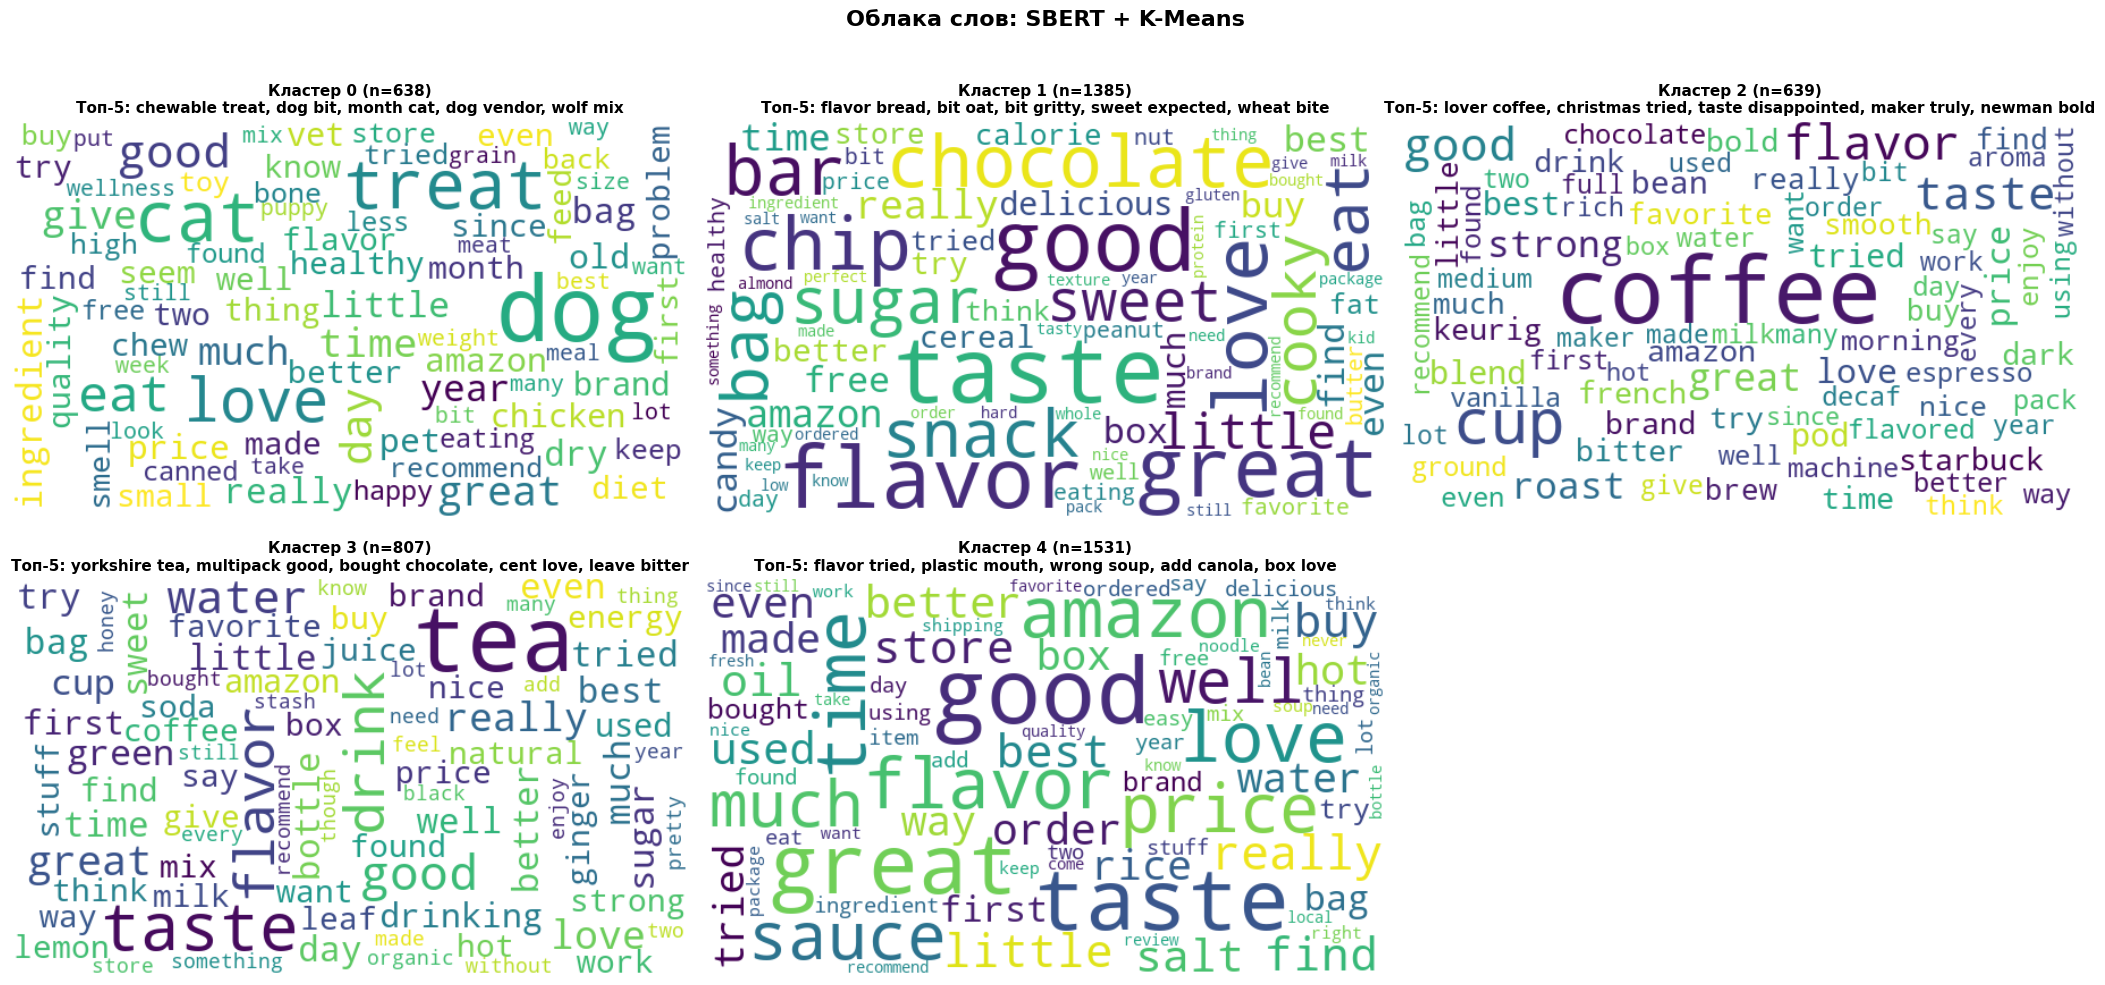

✅ Сохранено: wordclouds_sbert.png


In [17]:
plot_wordclouds(
    df_col='text_lemma',
    labels=df['cluster_sbert'],
    top_words_dict=top_words_sbert,
    method_name='SBERT + K-Means',
    filename='wordclouds_sbert.png'
)

## 10. Интерпретация кластеров

In [18]:
print("="*65)
print("ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (TF-IDF + K-Means)")
print("="*65)
for cl in range(N_CLUSTERS):
    words = [w for w, _ in top_words_tfidf[cl][:10]]
    n = (labels_tfidf == cl).sum()
    print(f"\nКластер {cl} ({n} отзывов, {n/len(df)*100:.1f}%)")
    print(f"  Топ-слова: {', '.join(words)}")

    # Примеры отзывов
    samples = df[df['cluster_tfidf'] == cl]['Text'].head(2).tolist()
    for i, s in enumerate(samples, 1):
        print(f"  Пример {i}: {s[:150]}...")

print("\n" + "="*65)
print("ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (SBERT + K-Means)")
print("="*65)
for cl in range(N_CLUSTERS):
    words = [w for w, _ in top_words_sbert[cl][:10]]
    n = (labels_sbert == cl).sum()
    print(f"\nКластер {cl} ({n} отзывов, {n/len(df)*100:.1f}%)")
    print(f"  Ключевые фразы (KeyBERT): {', '.join(words)}")

    samples = df[df['cluster_sbert'] == cl]['Text'].head(2).tolist()
    for i, s in enumerate(samples, 1):
        print(f"  Пример {i}: {s[:150]}...")

ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (TF-IDF + K-Means)

Кластер 0 (2453 отзывов, 49.1%)
  Топ-слова: good, great, taste, price, flavor, amazon, love, time, store, buy
  Пример 1: A little less than I expected.  It tends to have a muddy taste - not what I expected since they said it was the favorite of the company....
  Пример 2: and I want to congratulate the graphic artist for putting the entire product name on such a small box.  The ad men must have really thought long and h...

Кластер 1 (412 отзывов, 8.2%)
  Топ-слова: tea, green tea, taste, green, flavor, drink, bag, cup, tea bag, good
  Пример 1: I absolutely love Yorkshire tea and am so glad it is now available on Amazon!  A cup of this full-bodied black tea with milk in the morning is how I s...
  Пример 2: I have such a hard time finding loose tea locally. Being able to order my favorite Lady Grey tea on Amazon is convenient and timesaving. The tea comes...

Кластер 2 (566 отзывов, 11.3%)
  Топ-слова: dog, treat, cat, love, dog love, eat,

In [19]:
# Сводная таблица: размер кластеров + средний рейтинг (Score)
summary = pd.DataFrame({
    'Кластер': range(N_CLUSTERS),
    'Размер (TF-IDF)': [(labels_tfidf == c).sum() for c in range(N_CLUSTERS)],
    'Средний Score (TF-IDF)': [df[df['cluster_tfidf'] == c]['Score'].mean().round(2) for c in range(N_CLUSTERS)],
    'Размер (SBERT)': [(labels_sbert == c).sum() for c in range(N_CLUSTERS)],
    'Средний Score (SBERT)': [df[df['cluster_sbert'] == c]['Score'].mean().round(2) for c in range(N_CLUSTERS)],
})
print("\nСводная таблица кластеров:")
print(summary.to_string(index=False))


Сводная таблица кластеров:
 Кластер  Размер (TF-IDF)  Средний Score (TF-IDF)  Размер (SBERT)  Средний Score (SBERT)
       0             2453                    4.10             638                   4.14
       1              412                    4.39            1385                   4.29
       2              566                    4.15             639                   4.25
       3              557                    4.22             807                   4.22
       4             1012                    4.36            1531                   4.10


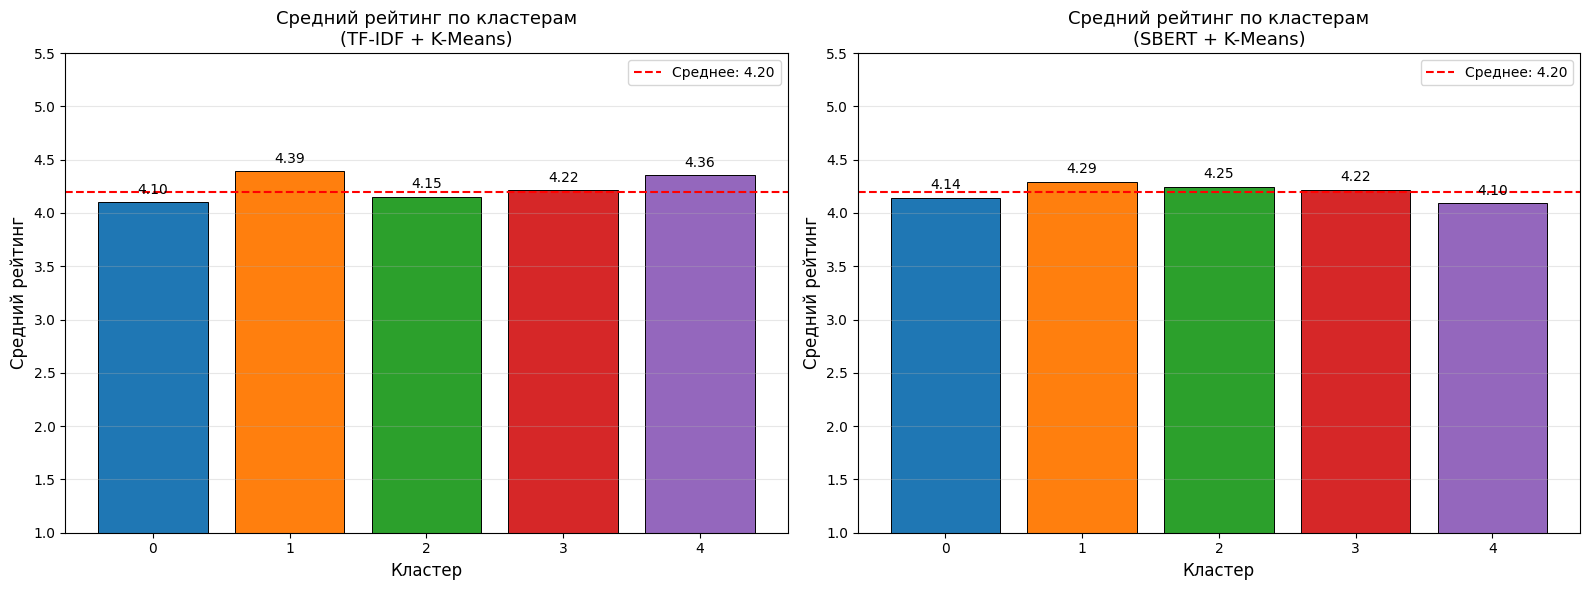

In [20]:
# График: распределение рейтингов по кластерам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(axes,
                           ['cluster_tfidf', 'cluster_sbert'],
                           ['TF-IDF + K-Means', 'SBERT + K-Means']):
    score_means = df.groupby(col)['Score'].mean().reset_index()
    bars = ax.bar(score_means[col].astype(str), score_means['Score'],
                  color=plt.cm.tab10.colors[:N_CLUSTERS], edgecolor='black', linewidth=0.7)
    ax.set_xlabel('Кластер', fontsize=12)
    ax.set_ylabel('Средний рейтинг', fontsize=12)
    ax.set_title(f'Средний рейтинг по кластерам\n({title})', fontsize=13)
    ax.set_ylim(1, 5.5)
    ax.axhline(y=df['Score'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Score"].mean():.2f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, score_means['Score']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('score_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Итоговые выводы

> **Заполните этот раздел после запуска ноутбука на основе реальных результатов.**

### Сравнение методов векторизации

| Критерий | TF-IDF | SBERT |
|---|---|---|
| Тип признаков | Частотные / статистические | Семантические / контекстные |
| Размерность | ~5000 (словарь) | 384 (вектор предложения) |
| Silhouette | *см. ячейку метрик* | *см. ячейку метрик* |
| Davies-Bouldin | *см. ячейку метрик* | *см. ячейку метрик* |
| Интерпретируемость кластеров | Высокая (ключевые слова из центроидов) | Средняя (через KeyBERT) |

### Описание кластеров

После анализа облаков слов и топ-слов каждому кластеру можно присвоить тематическую метку:

**TF-IDF:**
- Кластер 0: *впишите тему*
- Кластер 1: *впишите тему*
- ...

**SBERT:**
- Кластер 0: *впишите тему*
- Кластер 1: *впишите тему*
- ...